In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_excel("Online Retail.xlsx")

print("Dataset shape:", df.shape)

Dataset shape: (541909, 8)


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [6]:
df = df.drop_duplicates()

df = df[df["Quantity"] > 0]

df = df[df["UnitPrice"] > 0]

df = df.dropna(subset=["CustomerID"])

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (392692, 9)


In [7]:
df[["Quantity", "UnitPrice", "TotalAmount"]].describe()

,Quantity,UnitPrice,TotalAmount
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,22.631500
std,180.492832,22.241836,311.099224
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.450000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [8]:
df["Country"].value_counts().head(10)

Country
United Kingdom    349203
Germany             9025
France              8326
EIRE                7226
Spain               2479
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1453
Australia           1181
Name: count, dtype: int64

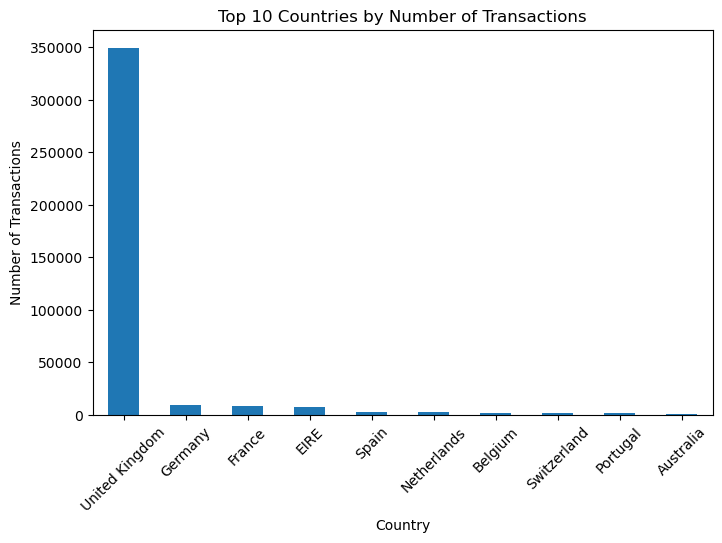

In [9]:
plt.figure(figsize=(8, 5))

df["Country"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

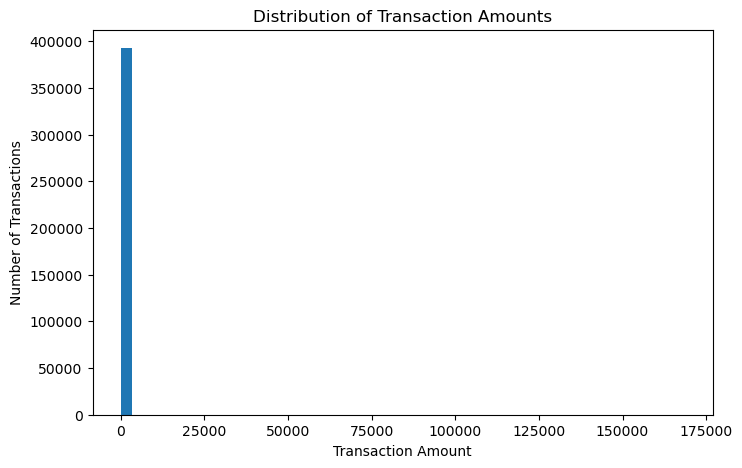

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(df["TotalAmount"], bins=50)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.show()

In [11]:
cutoff_date = pd.Timestamp("2011-09-01")

historical_data = df[df["InvoiceDate"] < cutoff_date].copy()

future_data = df[df["InvoiceDate"] >= cutoff_date].copy()

print("Historical transactions:", historical_data.shape)
print("Future transactions:", future_data.shape)

Historical transactions: (224036, 9)
Future transactions: (168656, 9)


In [12]:
customer_data = historical_data.groupby("CustomerID").agg({
    "InvoiceDate": ["min", "max"],
    "InvoiceNo": "nunique",
    "Quantity": "sum",
    "TotalAmount": "sum"
})

customer_data.columns = [
    "FirstPurchase",
    "LastPurchase",
    "Frequency",
    "TotalItems",
    "Monetary"
]

customer_data["Recency"] = (
    cutoff_date - customer_data["LastPurchase"]
).dt.days

customer_data["AverageOrderValue"] = (
    customer_data["Monetary"] / customer_data["Frequency"]
)

customer_data["Tenure"] = (
    cutoff_date - customer_data["FirstPurchase"]
).dt.days

customer_data.head()

,FirstPurchase,LastPurchase,Frequency,TotalItems,Monetary,Recency,AverageOrderValue,Tenure
CustomerID,,,,,,,,
12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,1,74215,77183.60,225,77183.600000,225
12347.0,2010-12-07 14:57:00,2011-08-02 08:48:00,5,1590,2790.86,29,558.172000,267
12348.0,2010-12-16 19:09:00,2011-04-05 10:47:00,3,2124,1487.24,148,495.746667,258
12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,197,334.40,210,334.400000,210
12352.0,2011-02-16 12:33:00,2011-03-22 16:08:00,5,254,1561.81,162,312.362000,196


In [13]:
future_customers = future_data["CustomerID"].unique()

customer_data["Churn"] = (
    ~customer_data.index.isin(future_customers)
).astype(int)

customer_data["Churn"].value_counts()

Churn
0    1952
1    1365
Name: count, dtype: int64

In [14]:
customer_data.shape

(3317, 9)

In [15]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "TotalItems",
    "Tenure"
]

X = customer_data[features]
y = customer_data["Churn"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2653, 6)
Testing data: (664, 6)


In [17]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [18]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.6446
Precision: 0.5703
Recall   : 0.5495
F1 Score : 0.5597
ROC-AUC  : 0.7021


In [20]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[278 113]
 [123 150]]


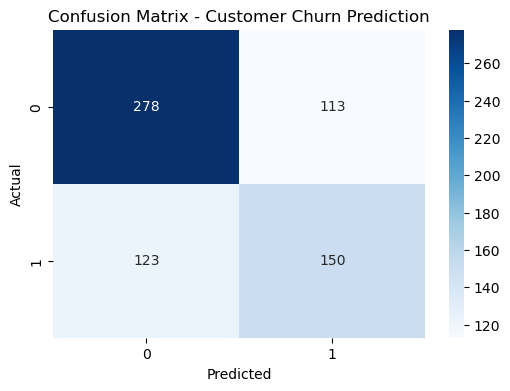

In [21]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Customer Churn Prediction")

plt.show()

In [23]:
joblib.dump(model, "churn_model.pkl")

print("Clean churn model saved successfully!")

Clean churn model saved successfully!


In [25]:
customer_data.to_csv("customer_features.csv")

print("Customer dataset saved successfully!")

Customer dataset saved successfully!
